# Functional Acceptance Failure Attribution

This notebook is intentionally separate from `analysis.ipynb`. It investigates why task-level functional acceptance tests fail: resolved interface representation differences, unresolved interface differences, likely requirement non-compliance, test-harness context problems, infrastructure failures, and possible cascades from a shared prerequisite failure.

The notebook reads only standardized CSVs produced by `src/ingest.py`; it does not scan raw experiment JSON. Automatic attribution is conservative: `interface_unresolved` and `requirement_noncompliance_candidate` are review queues, not confirmed conclusions.

In [1]:
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

ANALYSIS_DIR = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
sys.path.insert(0, str(ANALYSIS_DIR / "src"))
from paths import DATA_DIR  # noqa: E402

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 180)
sns.set_theme(style="whitegrid", context="notebook")

FAILURES_PATH = DATA_DIR / "acceptance_failures.csv"
COMPLETION_PATH = DATA_DIR / "task_completion.csv"
if not FAILURES_PATH.exists():
    raise FileNotFoundError("Run: python3 src/ingest.py (acceptance_failures.csv is missing)")

failures = pd.read_csv(FAILURES_PATH)
task_completion = pd.read_csv(COMPLETION_PATH)
for frame in (failures, task_completion):
    frame["condition"] = frame["agent"].astype(str) + " / " + frame["strategy"].astype(str)

print("Selected task runs:", len(task_completion))
print("Failure diagnostic events:", len(failures))

Selected task runs: 16
Failure diagnostic events: 181


## Reading the attribution labels

- **interface_variance_resolved** is represented at suite level by `adapted_pass`: the adapter normalized a naming/route/UI difference and the behavioral assertions passed.
- **interface_unresolved** means the evaluator could not map an interface representation. It does not prove the feature is missing.
- **interface_contract_variance** indicates a success-status or similar transport-contract difference that still needs review against the prompt variant.
- **requirement_noncompliance_candidate** means the assertion failed after available transport adaptation; it is the strongest automatic signal of an unimplemented requirement, but still needs evidence review.
- **test_harness_context** and **infrastructure_error** describe evaluator/runtime problems rather than product behavior.

Counts below are diagnostic events, not automatically independent defects.

test_status,pass,fail,error
condition,,,
claude / minimal,2,1,0
claude / structured,1,2,0
codex / minimal,1,2,0
codex / structured,1,2,0


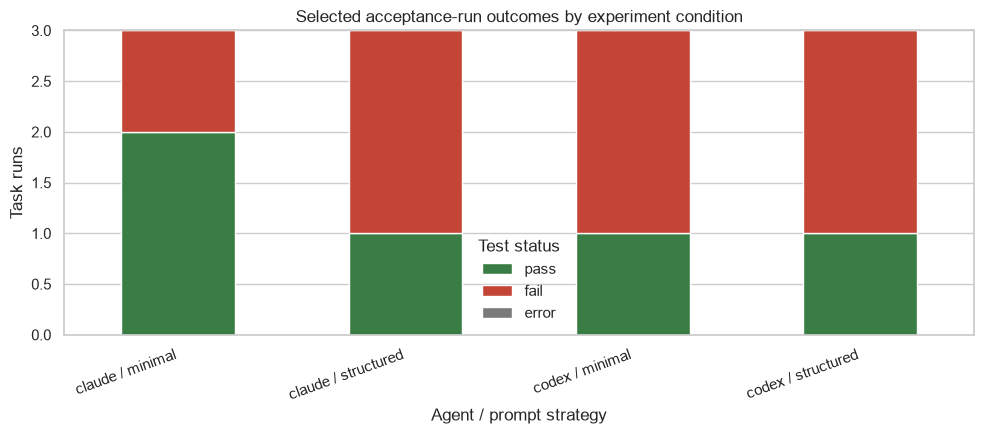

In [2]:
status_rows = task_completion.loc[
    ~task_completion["test_status"].isin(["no_data", "skipped"])
].copy()
status_order = ["pass", "fail", "error"]
status_counts = pd.crosstab(status_rows["condition"], status_rows["test_status"])
status_counts = status_counts.reindex(columns=status_order, fill_value=0)
display(status_counts)

ax = status_counts.plot(kind="bar", stacked=True, figsize=(10, 4.5), color=["#3a7d44", "#c44536", "#7a7a7a"])
ax.set_title("Selected acceptance-run outcomes by experiment condition")
ax.set_xlabel("Agent / prompt strategy")
ax.set_ylabel("Task runs")
ax.legend(title="Test status", frameon=False)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## Frontend and backend pass status by experiment condition

Each selected task run contributes one backend suite and one frontend suite. The first table shows the exact T1/T2/T3 result for every Agent/strategy condition; the second table and heatmap aggregate those results into suite-level pass rates.

task_id                  T1               T2               T3         
suite_id            backend frontend backend frontend backend frontend
condition                                                             
claude / minimal       PASS     PASS    PASS     PASS    FAIL     PASS
claude / structured    PASS     PASS    FAIL     PASS    FAIL     FAIL
codex / minimal        PASS     PASS    FAIL     FAIL    FAIL     FAIL
codex / structured     FAIL     PASS    FAIL     FAIL    PASS     PASS

passed / runs          pass_rate          
suite_id                  backend frontend   backend  frontend
condition                                                     
claude / minimal            2 / 3    3 / 3  0.666667       1.0
claude / structured         1 / 3    2 / 3  0.333333  0.666667
codex / minimal             1 / 3    1 / 3  0.333333  0.333333
codex / structured          1 / 3    2 / 3  0.333333  0.666667

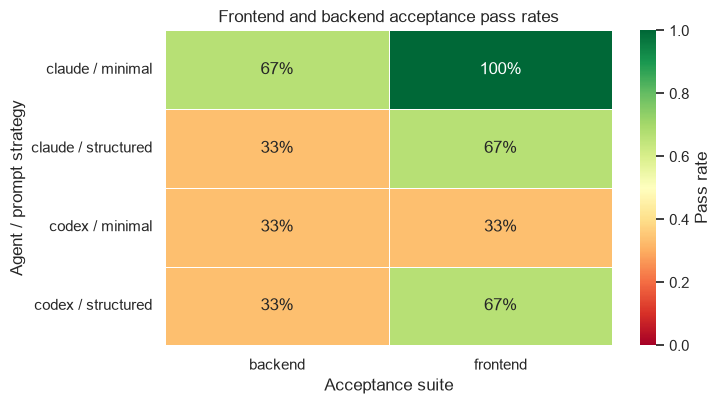

In [3]:
SUITE_ORDER = ["backend", "frontend"]
TASK_ORDER = ["T1", "T2", "T3"]

suite_records = []
for row in status_rows.itertuples():
    failed_suites = {
        value.strip()
        for value in str(row.test_failed_suite_ids).split("|")
        if value.strip() and value.strip().lower() != "nan"
    }
    for suite_id in SUITE_ORDER:
        if suite_id in failed_suites:
            suite_status = "fail"
        elif row.test_status == "error":
            suite_status = "error"
        else:
            suite_status = "pass"
        suite_records.append({
            "session_id": row.session_id,
            "task_id": row.task_id,
            "condition": row.condition,
            "suite_id": suite_id,
            "suite_status": suite_status,
        })

suite_results = pd.DataFrame(suite_records)
suite_results["task_id"] = pd.Categorical(suite_results["task_id"], TASK_ORDER, ordered=True)
suite_results["suite_id"] = pd.Categorical(suite_results["suite_id"], SUITE_ORDER, ordered=True)

detail_matrix = suite_results.pivot_table(
    index="condition", columns=["task_id", "suite_id"],
    values="suite_status", aggfunc="first", observed=False,
).replace({"pass": "PASS", "fail": "FAIL", "error": "ERROR"})
display(detail_matrix)

suite_summary = (
    suite_results.groupby(["condition", "suite_id"], observed=False)
    .agg(
        task_runs=("suite_status", "size"),
        passed=("suite_status", lambda values: int(values.eq("pass").sum())),
        failed=("suite_status", lambda values: int(values.eq("fail").sum())),
        errors=("suite_status", lambda values: int(values.eq("error").sum())),
    )
    .reset_index()
)
suite_summary["pass_rate"] = suite_summary["passed"] / suite_summary["task_runs"]
suite_summary["passed / runs"] = (
    suite_summary["passed"].astype(str) + " / " + suite_summary["task_runs"].astype(str)
)
summary_table = suite_summary.pivot(
    index="condition", columns="suite_id", values=["passed / runs", "pass_rate"]
)
display(summary_table)

pass_rate_matrix = suite_summary.pivot(index="condition", columns="suite_id", values="pass_rate")
pass_rate_matrix = pass_rate_matrix.reindex(columns=SUITE_ORDER)
plt.figure(figsize=(7.5, 4.2))
sns.heatmap(
    pass_rate_matrix, annot=True, fmt=".0%", vmin=0, vmax=1,
    cmap="RdYlGn", linewidths=0.7, cbar_kws={"label": "Pass rate"},
)
plt.title("Frontend and backend acceptance pass rates")
plt.xlabel("Acceptance suite")
plt.ylabel("Agent / prompt strategy")
plt.tight_layout()
plt.show()

## Resolved interface variance

A suite with `adapted_pass` used at least one route, field, response-envelope, HTTP-method, or UI-name adaptation and still passed the behavioral oracle. This is the clearest evidence that the Agent implemented the requirement but expressed the interface differently.

In [4]:
outcomes = task_completion[["session_id", "task_id", "condition", "adapter_outcomes"]].copy()
outcomes["outcome"] = outcomes["adapter_outcomes"].fillna("").str.split(" | ", regex=False)
outcomes = outcomes.explode("outcome")
adapted_passes = outcomes.loc[outcomes["outcome"].eq("adapted_pass")]
resolved_counts = (
    adapted_passes.groupby(["condition", "task_id"]).size()
    .rename("adapted_pass_suites").reset_index()
)
display(resolved_counts)
print("Resolved interface-variance suites:", len(adapted_passes))

,condition,task_id,adapted_pass_suites
0,claude / minimal,T1,2
1,claude / minimal,T2,2
2,claude / minimal,T3,1
3,claude / structured,T1,2
4,claude / structured,T2,1
5,codex / minimal,T1,2
6,codex / structured,T1,1
7,codex / structured,T3,2


Resolved interface-variance suites: 13


## Automatic failure-attribution profile

final_attribution,interface_unresolved,interface_contract_variance,requirement_noncompliance_candidate,test_harness_context,infrastructure_error,unclassified
condition,,,,,,
claude / minimal,0,0,1,0,0,0
claude / structured,1,0,88,0,0,0
codex / minimal,2,0,85,0,0,0
codex / structured,0,0,4,0,0,0


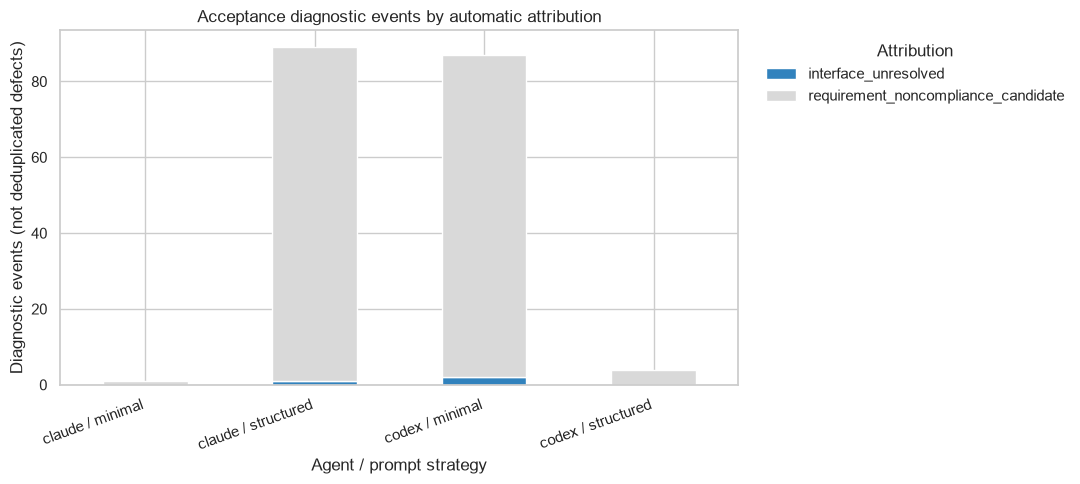

In [5]:
attribution_order = [
    "interface_unresolved",
    "interface_contract_variance",
    "requirement_noncompliance_candidate",
    "test_harness_context",
    "infrastructure_error",
    "unclassified",
]
attribution_counts = pd.crosstab(failures["condition"], failures["final_attribution"])
attribution_counts = attribution_counts.reindex(columns=attribution_order, fill_value=0)
display(attribution_counts)

plot_counts = attribution_counts.loc[:, attribution_counts.sum().gt(0)]
if not plot_counts.empty:
    ax = plot_counts.plot(kind="bar", stacked=True, figsize=(11, 5), colormap="tab20c")
    ax.set_title("Acceptance diagnostic events by automatic attribution")
    ax.set_xlabel("Agent / prompt strategy")
    ax.set_ylabel("Diagnostic events (not deduplicated defects)")
    ax.legend(title="Attribution", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()

## Where failures occur: task and suite

In [6]:
task_suite = (
    failures.groupby(["task_id", "suite_id", "final_attribution"]).size()
    .rename("events").reset_index()
    .sort_values(["task_id", "suite_id", "events"], ascending=[True, True, False])
)
display(task_suite)

raw_profile = (
    failures.groupby(["raw_classification", "final_attribution"]).size()
    .rename("events").reset_index().sort_values("events", ascending=False)
)
display(raw_profile)

,task_id,suite_id,final_attribution,events
0,T1,backend,requirement_noncompliance_candidate,1
2,T2,backend,requirement_noncompliance_candidate,53
1,T2,backend,interface_unresolved,1
3,T2,frontend,requirement_noncompliance_candidate,2
4,T3,backend,requirement_noncompliance_candidate,122
5,T3,frontend,interface_unresolved,2


,raw_classification,final_attribution,events
0,behaviour_or_unclassified,requirement_noncompliance_candidate,178
2,selector_variance,interface_unresolved,2
1,request_field,interface_unresolved,1


## Main frontend and backend test problems

The categories below are evidence-oriented root-cause summaries derived from the full failure id and message. `diagnostic_events` shows the visible blast radius, while `affected_task_runs` and `cascade_events` help avoid treating repeated downstream assertions as independent defects. Runtime connection resets remain separate from confirmed product defects.

,suite_id,problem_category,diagnostic_events,affected_task_runs,cascade_events,conditions,tasks
2,backend,Database migration / prerequisite cascade,88,2,88,claude / structured,"T2, T3"
1,backend,Contact-company request-field adapter gap,81,2,81,codex / minimal,"T2, T3"
7,backend,Runtime connection reset (indeterminate),3,2,2,"codex / minimal, codex / structured",T2
0,backend,Company-filter database query failure,1,1,0,codex / structured,T2
3,backend,Date representation mismatch,1,1,0,claude / minimal,T3
4,backend,Empty-update validation missing,1,1,0,codex / structured,T1
5,backend,Migrated primary-company response mismatch,1,1,1,codex / minimal,T2
6,backend,Required multi-company seed data missing,1,1,1,codex / minimal,T2
8,frontend,Contact-removal UI detection/behavior,2,2,0,"codex / minimal, codex / structured",T2
9,frontend,Transition error not shown inline,2,2,0,"claude / structured, codex / minimal",T3


,condition,suite_id,problem_category,diagnostic_events,affected_tasks
0,claude / minimal,backend,Date representation mismatch,1,T3
1,claude / structured,backend,Database migration / prerequisite cascade,88,"T2, T3"
2,claude / structured,frontend,Transition error not shown inline,1,T3
3,codex / minimal,backend,Contact-company request-field adapter gap,81,"T2, T3"
6,codex / minimal,backend,Runtime connection reset (indeterminate),2,T2
4,codex / minimal,backend,Migrated primary-company response mismatch,1,T2
5,codex / minimal,backend,Required multi-company seed data missing,1,T2
7,codex / minimal,frontend,Contact-removal UI detection/behavior,1,T2
8,codex / minimal,frontend,Transition error not shown inline,1,T3
9,codex / structured,backend,Company-filter database query failure,1,T2


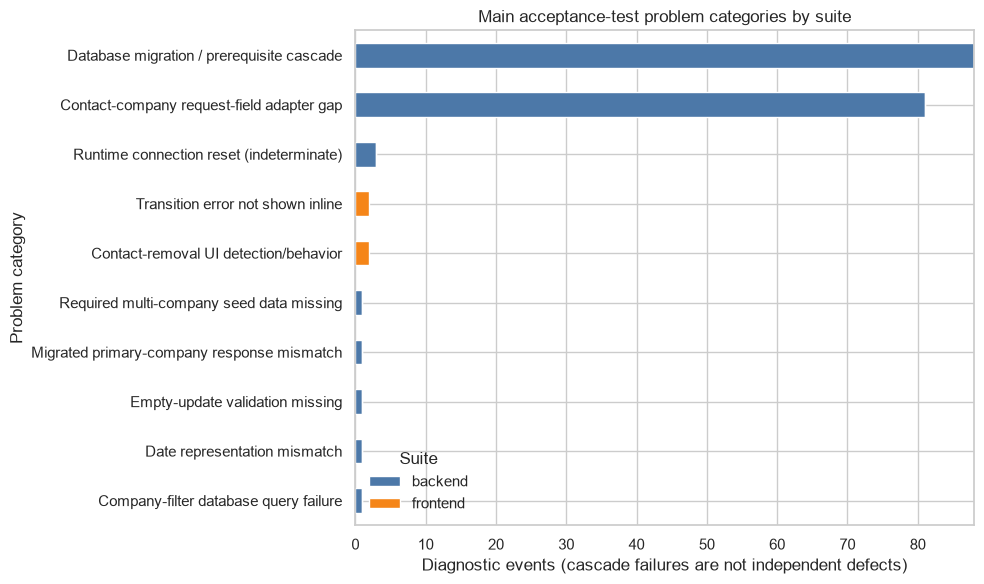

In [7]:
def classify_problem(row):
    failure_id = "" if pd.isna(row.failure_id) else str(row.failure_id)
    message = "" if pd.isna(row.failure_message) else str(row.failure_message)
    evidence = f"{failure_id} {message}".lower()

    if "econnreset" in evidence:
        return "Runtime connection reset (indeterminate)"
    if 'column "companyid" referenced in foreign key constraint does not exist' in evidence:
        return "Database migration / prerequisite cascade"
    if (
        "unresolved request_field for contact.companies" in evidence
        or "could not discover a valid contact link contract" in evidence
        or row.event_type == "adapter_unresolved"
    ):
        return "Contact-company request-field adapter gap"
    if "expectedclosedate" in evidence and "2026-12-31t00:00:00.000z" in evidence:
        return "Date representation mismatch"
    if "shows a transition api error inline" in evidence:
        return "Transition error not shown inline"
    if "selected deal contact" in evidence and "removable" in evidence:
        return "Contact-removal UI detection/behavior"
    if "rejects an empty body" in evidence:
        return "Empty-update validation missing"
    if "contact list and company filtering" in evidence and "expected 200" in evidence:
        return "Company-filter database query failure"
    if "relationship migration" in evidence and "isprimary" in evidence:
        return "Migrated primary-company response mismatch"
    if "demo seed includes a multi-company contact" in evidence:
        return "Required multi-company seed data missing"
    return "Other behavioral assertion"

problem_events = failures.copy()
problem_events["problem_category"] = problem_events.apply(classify_problem, axis=1)
problem_events["task_run"] = problem_events["session_id"].astype(str) + " / " + problem_events["task_id"].astype(str)
problem_events["message_excerpt"] = problem_events["failure_message"].map(lambda value: clean_excerpt(value, 220) if "clean_excerpt" in globals() else str(value)[:220])

suite_problem_summary = (
    problem_events.groupby(["suite_id", "problem_category"], as_index=False)
    .agg(
        diagnostic_events=("failure_id", "size"),
        affected_task_runs=("task_run", "nunique"),
        cascade_events=("cascade_candidate", lambda values: int(values.fillna(False).astype(bool).sum())),
        conditions=("condition", lambda values: ", ".join(sorted(set(values)))),
        tasks=("task_id", lambda values: ", ".join(sorted(set(values)))),
    )
    .sort_values(["suite_id", "diagnostic_events"], ascending=[True, False])
)
display(suite_problem_summary)

condition_problem_summary = (
    problem_events.groupby(["condition", "suite_id", "problem_category"], as_index=False)
    .agg(
        diagnostic_events=("failure_id", "size"),
        affected_tasks=("task_id", lambda values: ", ".join(sorted(set(values)))),
    )
    .sort_values(["condition", "suite_id", "diagnostic_events"], ascending=[True, True, False])
)
display(condition_problem_summary)

problem_chart = suite_problem_summary.pivot(
    index="problem_category", columns="suite_id", values="diagnostic_events"
).fillna(0)
problem_chart = problem_chart.reindex(columns=SUITE_ORDER, fill_value=0)
problem_chart = problem_chart.loc[problem_chart.sum(axis=1).sort_values().index]
ax = problem_chart.plot(
    kind="barh", stacked=True, figsize=(10, 6),
    color={"backend": "#4C78A8", "frontend": "#F58518"},
)
ax.set_title("Main acceptance-test problem categories by suite")
ax.set_xlabel("Diagnostic events (cascade failures are not independent defects)")
ax.set_ylabel("Problem category")
ax.legend(title="Suite", frameon=False)
plt.tight_layout()
plt.show()

## Cascade candidates

A suite is marked as a cascade candidate when at least three assertions fail and at least half of the suite fails. This does not prove dependency between failures; it identifies runs where one prerequisite failure (for example, migration or entity creation) may have produced many downstream failures. Review the earliest checkpoint and repeated stack trace before counting individual defects.

In [8]:
cascade = (
    failures.loc[failures["cascade_candidate"].fillna(False).astype(bool)]
    .groupby(["session_id", "task_id", "condition", "suite_id"], as_index=False)
    .agg(
        diagnostic_events=("failure_id", "size"),
        suite_total=("suite_total", "max"),
        suite_failed=("suite_failed", "max"),
        suite_failure_rate=("suite_failure_rate", "max"),
        first_checkpoint=("checkpoint", "min"),
    )
    .sort_values(["suite_failure_rate", "diagnostic_events"], ascending=False)
)
display(cascade if not cascade.empty else pd.DataFrame({"result": ["No cascade candidates"]}))

,session_id,task_id,condition,suite_id,diagnostic_events,suite_total,suite_failed,suite_failure_rate,first_checkpoint
1,session_20260817_160757,T3,claude / structured,backend,62,62,62,1.000000,1.0
0,session_20260817_160757,T2,claude / structured,backend,26,26,26,1.000000,1.0
2,session_20260817_210911,T2,codex / minimal,backend,26,26,25,0.961538,1.0
3,session_20260817_210911,T3,codex / minimal,backend,59,62,59,0.951613,1.0


## Manual adjudication layer

Edit `MANUAL_OVERRIDES` only after reading the full failure evidence. Keys are `(test_run_id, suite_id, failure_id)`. Recommended final labels are:

- `interface_representation_variance_confirmed`
- `requirement_noncompliance_confirmed`
- `blocked_by_prerequisite`
- `test_harness_problem_confirmed`
- `infrastructure_error`
- `indeterminate`

Keeping overrides in this visible cell makes human judgment explicit and reproducible.

In [9]:
MANUAL_OVERRIDES = {
    # Example:
    # ("run-id", "backend", "full test id"): "requirement_noncompliance_confirmed",
}

failures["adjudicated_attribution"] = [
    MANUAL_OVERRIDES.get(
        (str(row.test_run_id), str(row.suite_id), str(row.failure_id)),
        row.final_attribution,
    )
    for row in failures.itertuples()
]

adjudicated_counts = (
    failures.groupby(["condition", "adjudicated_attribution"]).size()
    .rename("events").reset_index().sort_values(["condition", "events"], ascending=[True, False])
)
display(adjudicated_counts)

,condition,adjudicated_attribution,events
0,claude / minimal,requirement_noncompliance_candidate,1
2,claude / structured,requirement_noncompliance_candidate,88
1,claude / structured,interface_unresolved,1
4,codex / minimal,requirement_noncompliance_candidate,85
3,codex / minimal,interface_unresolved,2
5,codex / structured,requirement_noncompliance_candidate,4


## Evidence review queue

This table is the working list for deciding “interface difference” versus “requirement not implemented.” Start with unresolved interfaces, then high-failure-rate suites, then behavioral candidates. Failure messages are truncated here; the source CSV retains the complete text.

In [10]:
ANSI_RE = re.compile(r"\x1b\[[0-?]*[ -/]*[@-~]")

def clean_excerpt(value, limit=700):
    text = "" if pd.isna(value) else ANSI_RE.sub("", str(value))
    text = re.sub(r"\s+", " ", text).strip()
    return text if len(text) <= limit else text[:limit] + "…"

priority = {
    "interface_unresolved": 0,
    "interface_contract_variance": 1,
    "test_harness_context": 2,
    "requirement_noncompliance_candidate": 3,
    "infrastructure_error": 4,
    "unclassified": 5,
}
review_queue = failures.copy()
review_queue["priority"] = review_queue["final_attribution"].map(priority).fillna(9)
review_queue["message_excerpt"] = review_queue["failure_message"].map(clean_excerpt)
review_queue = review_queue.sort_values(
    ["priority", "cascade_candidate", "session_id", "task_order", "suite_id"],
    ascending=[True, False, True, True, True],
)
display(review_queue[[
    "session_id", "task_id", "condition", "suite_id", "failure_id",
    "raw_classification", "final_attribution", "cascade_candidate",
    "message_excerpt",
]].head(40))

,session_id,task_id,condition,suite_id,failure_id,raw_classification,final_attribution,cascade_candidate,message_excerpt
115,session_20260817_210911,T2,codex / minimal,backend,Contact.companies[].id,request_field,interface_unresolved,True,"[""id:400"", ""companyId:400""]"
89,session_20260817_160757,T3,claude / structured,frontend,T3 Deal stage frontend acceptance shows a transition API error inline and leaves the stage unchanged,selector_variance,interface_unresolved,False,Error: Unable to find an element with the text: Transition blocked by acceptance test. This could be because the text is broken up by mu...
176,session_20260817_210911,T3,codex / minimal,frontend,T3 Deal stage frontend acceptance shows a transition API error inline and leaves the stage unchanged,selector_variance,interface_unresolved,False,Error: Unable to find an element with the text: Transition blocked by acceptance test. This could be because the text is broken up by mu...
1,session_20260817_160757,T2,claude / structured,backend,T2 relationship API (e2e) checkpoint 1: Contact creation and representation creates a Contact linked to one Company and returns that pri...,behaviour_or_unclassified,requirement_noncompliance_candidate,True,"QueryFailedError: column ""companyId"" referenced in foreign key constraint does not exist at PostgresQueryRunner.query (/workspace/backen..."
2,session_20260817_160757,T2,claude / structured,backend,T2 relationship API (e2e) checkpoint 1: Contact creation and representation creates a multi-Company Contact and orders the primary Compa...,behaviour_or_unclassified,requirement_noncompliance_candidate,True,"QueryFailedError: column ""companyId"" referenced in foreign key constraint does not exist at PostgresQueryRunner.query (/workspace/backen..."
3,session_20260817_160757,T2,claude / structured,backend,T2 relationship API (e2e) checkpoint 1: Contact creation and representation rejects a Contact with no Company links,behaviour_or_unclassified,requirement_noncompliance_candidate,True,"QueryFailedError: column ""companyId"" referenced in foreign key constraint does not exist at PostgresQueryRunner.query (/workspace/backen..."
4,session_20260817_160757,T2,claude / structured,backend,T2 relationship API (e2e) checkpoint 1: Contact creation and representation rejects a Contact with no primary Company,behaviour_or_unclassified,requirement_noncompliance_candidate,True,"QueryFailedError: column ""companyId"" referenced in foreign key constraint does not exist at PostgresQueryRunner.query (/workspace/backen..."
5,session_20260817_160757,T2,claude / structured,backend,T2 relationship API (e2e) checkpoint 1: Contact creation and representation rejects a Contact with two primary Companies,behaviour_or_unclassified,requirement_noncompliance_candidate,True,"QueryFailedError: column ""companyId"" referenced in foreign key constraint does not exist at PostgresQueryRunner.query (/workspace/backen..."
6,session_20260817_160757,T2,claude / structured,backend,T2 relationship API (e2e) checkpoint 1: Contact creation and representation rejects an unknown Company and does not create the Contact,behaviour_or_unclassified,requirement_noncompliance_candidate,True,"QueryFailedError: column ""companyId"" referenced in foreign key constraint does not exist at PostgresQueryRunner.query (/workspace/backen..."
7,session_20260817_160757,T2,claude / structured,backend,T2 relationship API (e2e) checkpoint 2: atomic Contact-Company replacement atomically removes the old primary when the same operation de...,behaviour_or_unclassified,requirement_noncompliance_candidate,True,"QueryFailedError: column ""companyId"" referenced in foreign key constraint does not exist at PostgresQueryRunner.query (/workspace/backen..."


## Per-run drill-down

Set the two selectors to inspect one experiment step. If both are `None`, the notebook chooses the run with the most diagnostic events.

In [11]:
SELECTED_SESSION = None  # e.g. "session_20260817_130253"
SELECTED_TASK = None     # e.g. "T3"

if failures.empty:
    selected = failures.copy()
else:
    if SELECTED_SESSION is None or SELECTED_TASK is None:
        default_key = failures.groupby(["session_id", "task_id"]).size().idxmax()
        selected_session, selected_task = default_key
    else:
        selected_session, selected_task = SELECTED_SESSION, SELECTED_TASK
    selected = failures.loc[
        failures["session_id"].eq(selected_session)
        & failures["task_id"].eq(selected_task)
    ].copy()
    selected["message_excerpt"] = selected["failure_message"].map(lambda value: clean_excerpt(value, 1200))
    print("Selected:", selected_session, selected_task, "| events:", len(selected))
    display(selected[[
        "suite_id", "failure_id", "checkpoint", "raw_classification",
        "adjudicated_attribution", "attribution_confidence",
        "cascade_candidate", "message_excerpt",
    ]])

Selected: session_20260817_160757 T3 | events: 63


,suite_id,failure_id,checkpoint,raw_classification,adjudicated_attribution,attribution_confidence,cascade_candidate,message_excerpt
27,backend,T3 Deal pipeline API (e2e) checkpoint 1: controlled vocabulary and initial stage accepts lead as an initial stage,1.0,behaviour_or_unclassified,requirement_noncompliance_candidate,medium,True,"QueryFailedError: column ""companyId"" referenced in foreign key constraint does not exist at PostgresQueryRunner.query (/workspace/backen..."
28,backend,T3 Deal pipeline API (e2e) checkpoint 1: controlled vocabulary and initial stage accepts qualified as an initial stage,1.0,behaviour_or_unclassified,requirement_noncompliance_candidate,medium,True,"QueryFailedError: column ""companyId"" referenced in foreign key constraint does not exist at PostgresQueryRunner.query (/workspace/backen..."
29,backend,"T3 Deal pipeline API (e2e) checkpoint 1: controlled vocabulary and initial stage defaults an omitted stage to ""lead""",1.0,behaviour_or_unclassified,requirement_noncompliance_candidate,medium,True,"QueryFailedError: column ""companyId"" referenced in foreign key constraint does not exist at PostgresQueryRunner.query (/workspace/backen..."
30,backend,T3 Deal pipeline API (e2e) checkpoint 1: controlled vocabulary and initial stage rejects active as an initial stage,1.0,behaviour_or_unclassified,requirement_noncompliance_candidate,medium,True,"QueryFailedError: column ""companyId"" referenced in foreign key constraint does not exist at PostgresQueryRunner.query (/workspace/backen..."
31,backend,T3 Deal pipeline API (e2e) checkpoint 1: controlled vocabulary and initial stage rejects an unrecognised initial stage as UNKNOWN_STAGE,1.0,behaviour_or_unclassified,requirement_noncompliance_candidate,medium,True,"QueryFailedError: column ""companyId"" referenced in foreign key constraint does not exist at PostgresQueryRunner.query (/workspace/backen..."
...,...,...,...,...,...,...,...,...
85,backend,T3 Deal pipeline API (e2e) checkpoint 4: generic-update parity and errors updates a terminal Deal without revalidating stage when stage ...,4.0,behaviour_or_unclassified,requirement_noncompliance_candidate,medium,True,"QueryFailedError: column ""companyId"" referenced in foreign key constraint does not exist at PostgresQueryRunner.query (/workspace/backen..."
86,backend,T3 Deal stage migration (e2e) canonicalises every required legacy stage mapping and is safe to rerun,NaN,behaviour_or_unclassified,requirement_noncompliance_candidate,medium,True,"QueryFailedError: column ""companyId"" referenced in foreign key constraint does not exist at PostgresQueryRunner.query (/workspace/backen..."
87,backend,T3 seed scenarios (e2e) demo seed includes at least one Deal in every canonical stage,NaN,behaviour_or_unclassified,requirement_noncompliance_candidate,medium,True,"QueryFailedError: column ""companyId"" referenced in foreign key constraint does not exist at PostgresQueryRunner.query (/workspace/backen..."
88,backend,T3 seed scenarios (e2e) edge-case seed includes a zero-Contact Deal whose active transition fails its precondition,NaN,behaviour_or_unclassified,requirement_noncompliance_candidate,medium,True,"QueryFailedError: column ""companyId"" referenced in foreign key constraint does not exist at PostgresQueryRunner.query (/workspace/backen..."


## Interpretation summary

Use the following reading rule in reporting:

1. Count `adapted_pass` as fulfilled behavior with an interface representation difference.
2. Report `interface_unresolved` separately; do not count it as an Agent defect without review.
3. Treat `requirement_noncompliance_candidate` as a review queue, then confirm it from normalized behavioral evidence.
4. Collapse cascade failures to their shared prerequisite before reporting defect counts.
5. Keep infrastructure and test-harness problems outside Agent task-completion failure rates.

In [12]:
summary = pd.Series({
    "selected_task_runs": int(len(status_rows)),
    "passed_task_runs": int(status_rows["test_status"].eq("pass").sum()),
    "failed_task_runs": int(status_rows["test_status"].eq("fail").sum()),
    "resolved_interface_variance_suites": int(len(adapted_passes)),
    "unresolved_interface_events": int(failures["final_attribution"].eq("interface_unresolved").sum()),
    "requirement_noncompliance_candidates": int(failures["final_attribution"].eq("requirement_noncompliance_candidate").sum()),
    "cascade_candidate_events": int(failures["cascade_candidate"].fillna(False).astype(bool).sum()),
    "manual_overrides_applied": int(len(MANUAL_OVERRIDES)),
}, name="count")
display(summary.to_frame())

,count
selected_task_runs,12
passed_task_runs,5
failed_task_runs,7
resolved_interface_variance_suites,13
unresolved_interface_events,3
requirement_noncompliance_candidates,178
cascade_candidate_events,173
manual_overrides_applied,0
